# **Importing Dependencies**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.svm import SVC 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report, accuracy_score, f1_score

# **Importing Data**

In [2]:
data=pd.read_csv("../input/iris/Iris.csv")
data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


# **Data Pre-processing**

In [3]:
df=data.drop(["Id"],axis=1)
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


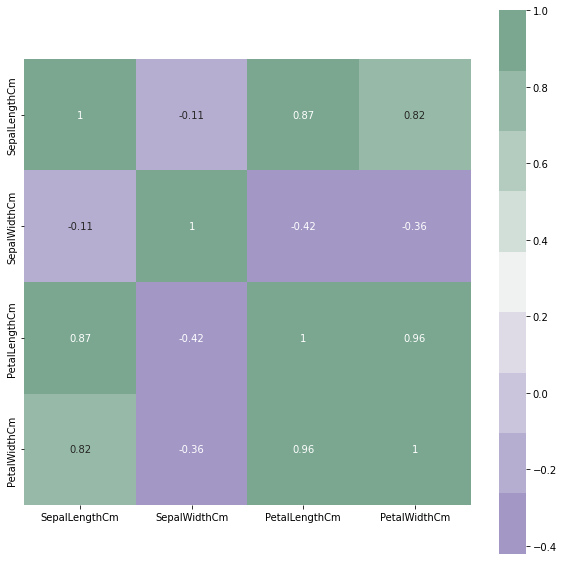

In [5]:
#Examaning a corelation matrix of all the features 
cmap = sns.diverging_palette(275,150,  s=40, l=65, n=9)
corrmat = df.corr()
plt.subplots(figsize=(10,10))
sns.heatmap(corrmat,cmap= cmap,annot=True, square=True);

<AxesSubplot:xlabel='Species', ylabel='count'>

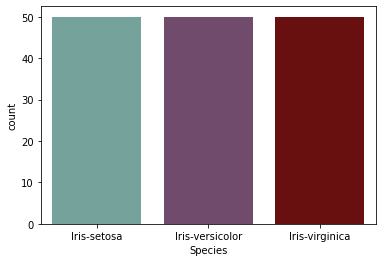

In [6]:
cols= ["#6daa9f","#774571","#770000"]
sns.countplot(x= df["Species"], palette= cols)

In [7]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [8]:
df1=df['Species']
df1.head()

0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object

In [9]:
X= df.drop(['Species'],axis='columns')
X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [10]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()

In [11]:
y=label_encoder.fit_transform(df1)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

# **Split the data and fit in model**

In [12]:
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=7)

In [13]:
clf = SVC() 
clf.fit(X_train, y_train) 
y_pred = clf.predict(X_test)
print('Accuracy Score: {:.4f}'.format(accuracy_score(y_test, y_pred)))
y_pred

Accuracy Score: 0.8684


array([2, 1, 0, 1, 1, 0, 1, 1, 0, 1, 2, 1, 0, 2, 0, 1, 2, 2, 0, 0, 1, 2,
       1, 1, 2, 1, 1, 1, 2, 2, 1, 1, 0, 2, 1, 0, 0, 0])

In [14]:
clf._get_param_names()

['C',
 'break_ties',
 'cache_size',
 'class_weight',
 'coef0',
 'decision_function_shape',
 'degree',
 'gamma',
 'kernel',
 'max_iter',
 'probability',
 'random_state',
 'shrinking',
 'tol',
 'verbose']

<AxesSubplot:>

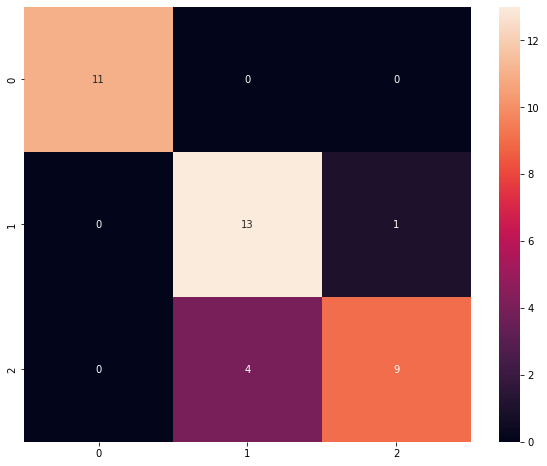

In [15]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(mat, annot=True)

**C  float, default=1.0
Regularization parameter. The strength of the regularization is inversely proportional to C. Must be strictly positive. The penalty is a squared l2 penalty.**

Accuracy Score: 0.9737


<AxesSubplot:>

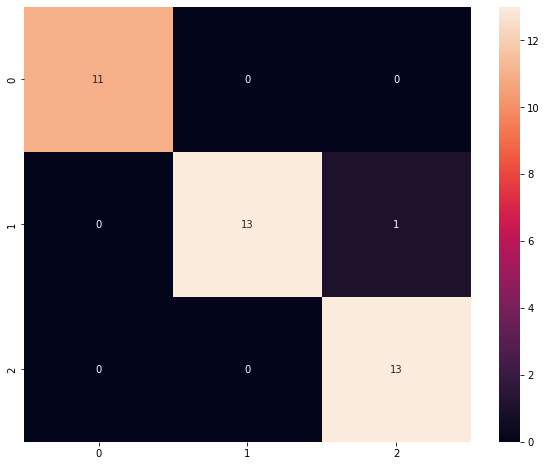

In [16]:
clf = SVC(C=5) 
clf.fit(X_train, y_train) 
y_pred = clf.predict(X_test)
print('Accuracy Score: {:.4f}'.format(accuracy_score(y_test, y_pred)))
y_pred
mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(mat, annot=True)

**kernel  {‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘precomputed’} or callable, default=’rbf’
Specifies the kernel type to be used in the algorithm. If none is given, ‘rbf’ will be used. If a callable is given it is used to pre-compute the kernel matrix from data matrices; that matrix should be an array of shape (n_samples, n_samples).**
**for precomputed matrix should be square 
**

Accuracy Score: 0.9737


<AxesSubplot:>

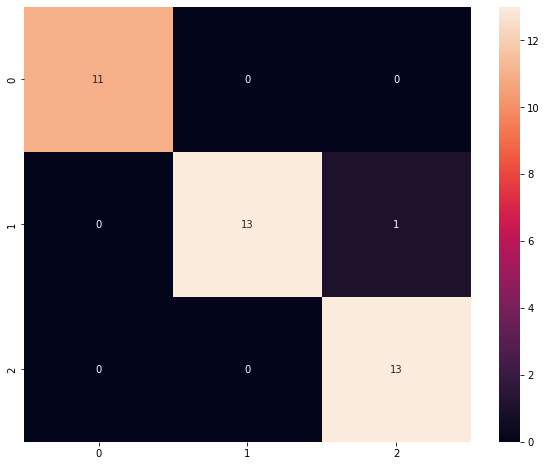

In [17]:
clf = SVC(kernel='linear') 
clf.fit(X_train, y_train) 
y_pred = clf.predict(X_test)
print('Accuracy Score: {:.4f}'.format(accuracy_score(y_test, y_pred)))
y_pred
mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(mat, annot=True)

Accuracy Score: 0.9211


<AxesSubplot:>

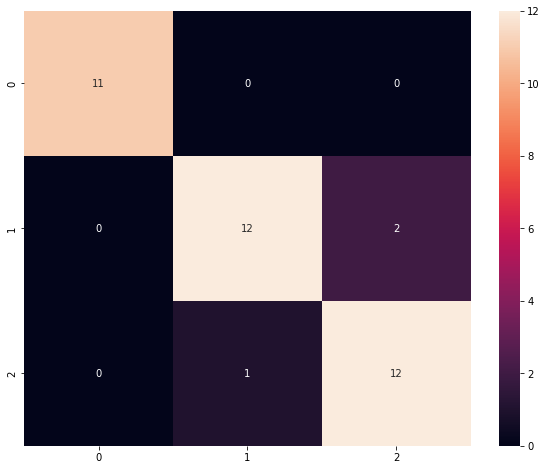

In [18]:
clf = SVC(kernel='poly') 
clf.fit(X_train, y_train) 
y_pred = clf.predict(X_test)
print('Accuracy Score: {:.4f}'.format(accuracy_score(y_test, y_pred)))
y_pred
mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(mat, annot=True)

Accuracy Score: 0.2895


<AxesSubplot:>

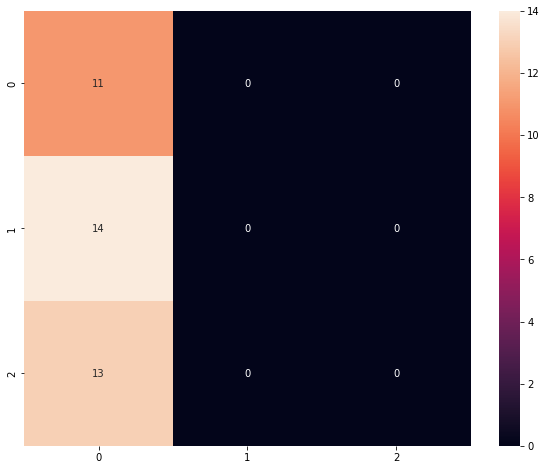

In [19]:
clf = SVC(kernel='sigmoid') 
clf.fit(X_train, y_train) 
y_pred = clf.predict(X_test)
print('Accuracy Score: {:.4f}'.format(accuracy_score(y_test, y_pred)))
y_pred
mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(mat, annot=True)

**degreeint, default=3
Degree of the polynomial kernel function (‘poly’). Ignored by all other kernels.**

Accuracy Score: 0.8684


<AxesSubplot:>

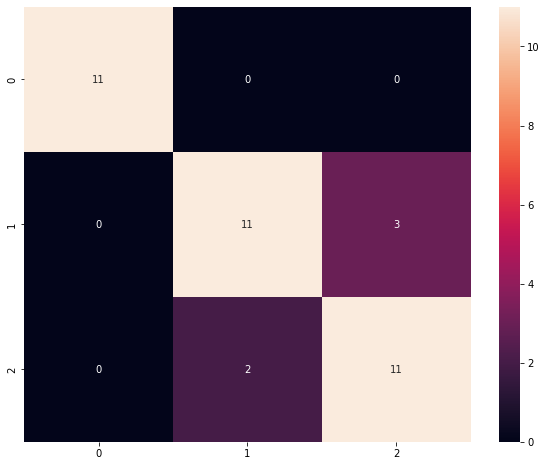

In [20]:
clf = SVC(kernel='poly',degree=8) 
clf.fit(X_train, y_train) 
y_pred = clf.predict(X_test)
print('Accuracy Score: {:.4f}'.format(accuracy_score(y_test, y_pred)))
y_pred
mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(mat, annot=True)

**gamma{‘scale’, ‘auto’} or float, default=’scale’**

Accuracy Score: 0.9211


<AxesSubplot:>

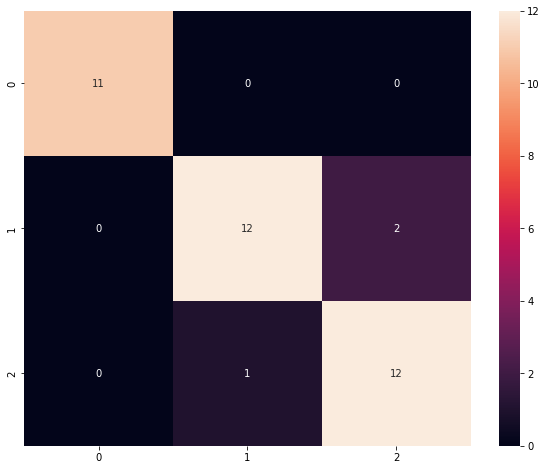

In [21]:
clf = SVC(gamma=1) 
clf.fit(X_train, y_train) 
y_pred = clf.predict(X_test)
print('Accuracy Score: {:.4f}'.format(accuracy_score(y_test, y_pred)))
y_pred
mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(mat, annot=True)

# For this particular dataset kernel=rbf and gamma=1 gives good accuracy if we increase or decrease the gamma value accuracy decreases 

**shrinkingbool, default=True
Whether to use the shrinking heuristic. See the User Guide.**

Accuracy Score: 0.9737


<AxesSubplot:>

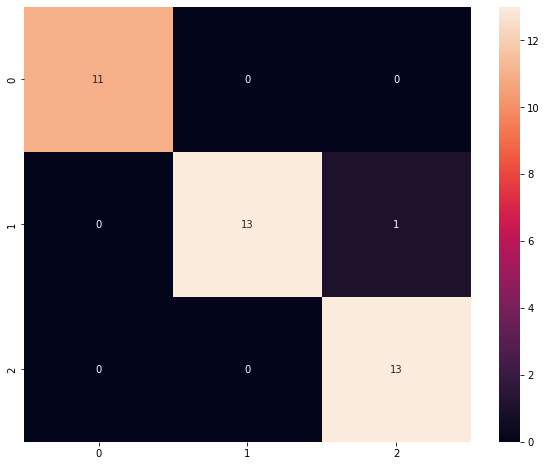

In [22]:
clf = SVC(kernel='linear',shrinking=False,C=1) 
clf.fit(X_train, y_train) 
y_pred = clf.predict(X_test)
print('Accuracy Score: {:.4f}'.format(accuracy_score(y_test, y_pred)))
y_pred
mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(mat, annot=True)

**probabilitybool, default=False
Whether to enable probability estimates. This must be enabled prior to calling fit, will slow down that method as it internally uses 5-fold cross-validation, and predict_proba may be inconsistent with predict. Read more in the User Guide.**

Accuracy Score: 0.9737


<AxesSubplot:>

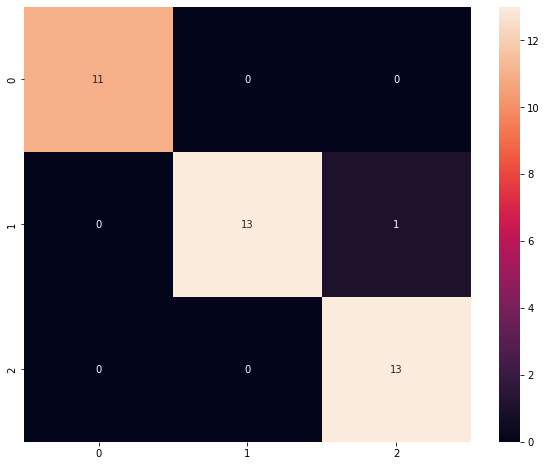

In [23]:
clf = SVC(kernel='linear',C=1,probability=False) 
clf.fit(X_train, y_train) 
y_pred = clf.predict(X_test)
print('Accuracy Score: {:.4f}'.format(accuracy_score(y_test, y_pred)))
y_pred
mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(mat, annot=True)

**tolfloat, default=1e-3
Tolerance for stopping criterion.**

Accuracy Score: 0.9474


<AxesSubplot:>

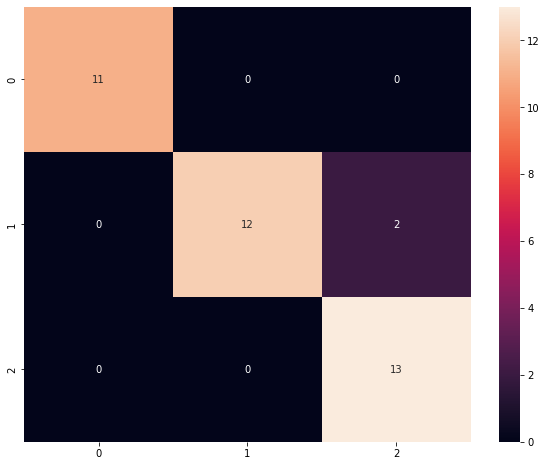

In [24]:
clf = SVC(kernel='linear',tol=1,C=5) 
clf.fit(X_train, y_train) 
y_pred = clf.predict(X_test)
print('Accuracy Score: {:.4f}'.format(accuracy_score(y_test, y_pred)))
y_pred
mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(mat, annot=True)

**decision_function_shape{‘ovo’, ‘ovr’}, default=’ovr’
Whether to return a one-vs-rest (‘ovr’) decision function of shape (n_samples, n_classes) as all other classifiers, or the original one-vs-one (‘ovo’) decision function of libsvm which has shape (n_samples, n_classes * (n_classes - 1) / 2). However, note that internally, one-vs-one (‘ovo’) is always used as a multi-class strategy to train models; an ovr matrix is only constructed from the ovo matrix. The parameter is ignored for binary classification.**

Accuracy Score: 0.9737


<AxesSubplot:>

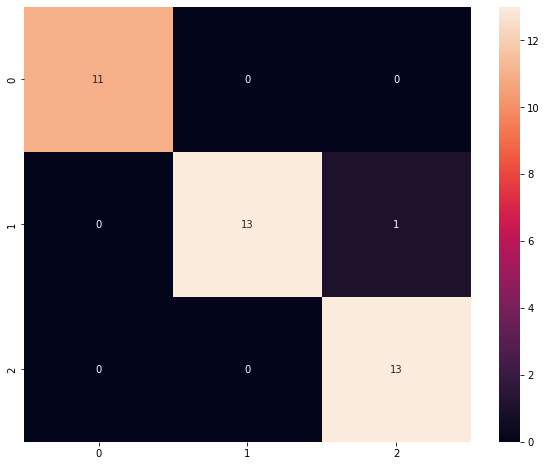

In [25]:
clf = SVC(kernel='linear',decision_function_shape='ovo') 
clf.fit(X_train, y_train) 
y_pred = clf.predict(X_test)
print('Accuracy Score: {:.4f}'.format(accuracy_score(y_test, y_pred)))
y_pred
mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(mat, annot=True)

**break_ties bool, default=False
If true, decision_function_shape='ovr', and number of classes > 2, predict will break ties according to the confidence values of decision_function; otherwise the first class among the tied classes is returned. Please note that breaking ties comes at a relatively high computational cost compared to a simple predict.**

Accuracy Score: 0.9737


<AxesSubplot:>

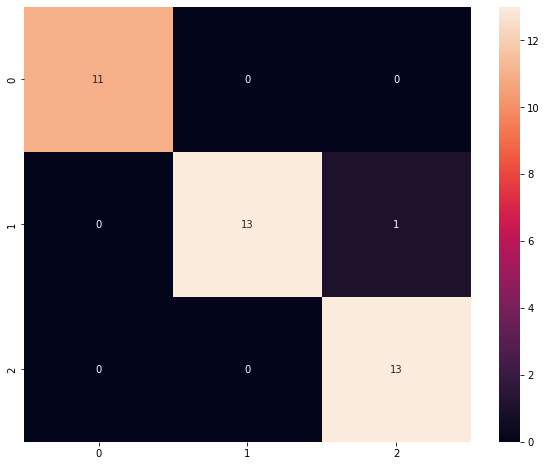

In [26]:
clf = SVC(break_ties=True,kernel='linear',C=1) 
clf.fit(X_train, y_train) 
y_pred = clf.predict(X_test)
print('Accuracy Score: {:.4f}'.format(accuracy_score(y_test, y_pred)))
y_pred
mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(mat, annot=True)

Accuracy Score: 0.9737


<AxesSubplot:>

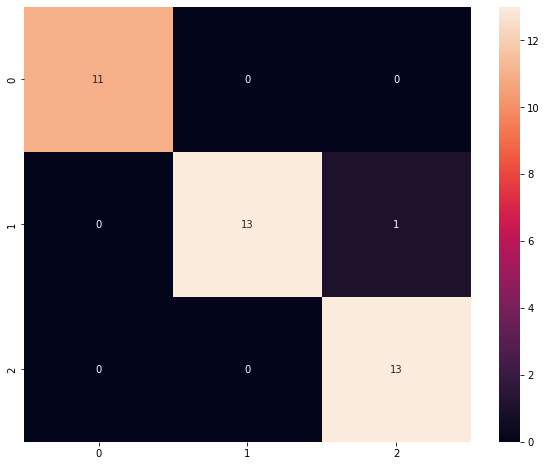

In [27]:
clf = SVC(C=1,kernel='linear',degree=5,gamma='auto',shrinking=True,decision_function_shape='ovr',break_ties=True) 
clf.fit(X_train, y_train) 
y_pred = clf.predict(X_test)
print('Accuracy Score: {:.4f}'.format(accuracy_score(y_test, y_pred)))
y_pred
mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(mat, annot=True)